**USE CASE 1 — Telecom SIM Activation & Fraud Verification Workflow**

In [14]:

!pip install langgraph langchain langchain-google-genai google-generativeai

In [15]:
#Installing the required dependencies
from langgraph.graph import StateGraph, START, END #START and END are dummy nodes in LangGraph
from typing import TypedDict #this is a special type of Dict where we specify the datatype also
from langchain_google_genai import ChatGoogleGenerativeAI #for getting a response from the LLM
from langchain_core.tools import tool
from IPython.display import Image #visualize the workflow created using LangGraph


In [ ]:
#Configuring the Gemini API
import os
os.environ["GOOGLE_API_KEY"]="API"

In [17]:

#Initializing the Gemini LLM
llm=ChatGoogleGenerativeAI(
    model='gemini-2.5-flash'
)

In [18]:

# -----------------------------------
# State Definition
# -----------------------------------

class TelecomState(TypedDict):
    customer_name: str
    aadhaar_valid: bool
    pan_valid: bool
    location: str
    previous_sim_requests: int

    kyc_status: str
    fraud_risk: str
    final_decision: str


In [19]:

# -----------------------------------
# STEP 1 — KYC VERIFICATION TOOL
# -----------------------------------

def kyc_verification_tool(state: TelecomState):

    if state["aadhaar_valid"] and state["pan_valid"]:
        kyc_status = "VERIFIED"

    elif not state["aadhaar_valid"] and not state["pan_valid"]:
        kyc_status = "INVALID_DOCUMENT"

    else:
        kyc_status = "PENDING_VERIFICATION"

    print("\n===== STEP 1: KYC VERIFICATION =====")
    print("KYC STATUS:", kyc_status)

    return {
        **state,
        "kyc_status": kyc_status
    }


In [20]:

# -----------------------------------
# STEP 2 — FRAUD DETECTION USING GEMINI
# -----------------------------------

def fraud_detection_node(state: TelecomState):

    prompt = f"""
    You are a telecom fraud detection AI.

    Analyze the following customer data:

    Location: {state['location']}
    Previous SIM Requests: {state['previous_sim_requests']}
    KYC Status: {state['kyc_status']}

    Classify fraud risk into:
    - LOW_RISK
    - MEDIUM_RISK
    - HIGH_RISK

    Return ONLY the classification.
    """

    response = llm.invoke(prompt)

    fraud_risk = response.content.strip()

    print("\n===== STEP 2: FRAUD DETECTION =====")
    print("FRAUD RISK:", fraud_risk)

    return {
        **state,
        "fraud_risk": fraud_risk
    }

In [21]:

# -----------------------------------
# STEP 3 — FINAL ACTIVATION DECISION
# -----------------------------------

def activation_decision_node(state: TelecomState):

    if state["fraud_risk"] == "LOW_RISK":
        decision = "SIM Activated"

    elif state["fraud_risk"] == "MEDIUM_RISK":
        decision = "Manual Review"

    else:
        decision = "Reject Application"

    print("\n===== STEP 3: FINAL DECISION =====")
    print("FINAL DECISION:", decision)

    return {
        **state,
        "final_decision": decision
    }


In [22]:

# -----------------------------------
# BUILD LANGGRAPH WORKFLOW
# -----------------------------------

graph = StateGraph(TelecomState)

graph.add_node("kyc_verification", kyc_verification_tool)
graph.add_node("fraud_detection", fraud_detection_node)
graph.add_node("activation_decision", activation_decision_node)

graph.set_entry_point("kyc_verification")

graph.add_edge("kyc_verification", "fraud_detection")
graph.add_edge("fraud_detection", "activation_decision")
graph.add_edge("activation_decision", END)

workflow = graph.compile()


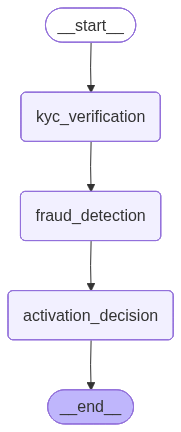

In [23]:
workflow

In [24]:
# -----------------------------------
# SAMPLE INPUT
# -----------------------------------

input_data = {
    "customer_name": "Rahul Varma",
    "aadhaar_valid": True,
    "pan_valid": True,
    "location": "Trivandrum",
    "previous_sim_requests": 1
}

In [25]:
# -----------------------------------
# RUN WORKFLOW
# -----------------------------------

result = workflow.invoke(input_data)

print("\n===== FINAL WORKFLOW OUTPUT =====")
print(result)


===== STEP 1: KYC VERIFICATION =====
KYC STATUS: VERIFIED

===== STEP 2: FRAUD DETECTION =====
FRAUD RISK: LOW_RISK

===== STEP 3: FINAL DECISION =====
FINAL DECISION: SIM Activated

===== FINAL WORKFLOW OUTPUT =====
{'customer_name': 'Rahul Varma', 'aadhaar_valid': True, 'pan_valid': True, 'location': 'Trivandrum', 'previous_sim_requests': 1, 'kyc_status': 'VERIFIED', 'fraud_risk': 'LOW_RISK', 'final_decision': 'SIM Activated'}


**USE CASE 2 — Healthcare Appointment Prioritization Workflow**

In [26]:
# -----------------------------------
# STATE DEFINITION
# -----------------------------------

class HealthcareState(TypedDict):
    patient_name: str
    fever: float
    oxygen_level: int
    heart_rate: int
    symptom_duration: int
    age: int
    existing_conditions: str

    severity: str
    priority: str
    consultation_assignment: str

In [27]:
# -----------------------------------
# STEP 1 — SYMPTOM SEVERITY TOOL
# -----------------------------------

def symptom_severity_tool(state: HealthcareState):

    oxygen = state["oxygen_level"]
    fever = state["fever"]
    heart_rate = state["heart_rate"]
    duration = state["symptom_duration"]

    if oxygen < 90 or fever > 103 or heart_rate > 130:
        severity = "CRITICAL"

    elif oxygen < 95 or fever > 100:
        severity = "MODERATE"

    else:
        severity = "STABLE"

    print("\n===== STEP 1: SYMPTOM ANALYSIS =====")
    print("SEVERITY:", severity)

    return {
        **state,
        "severity": severity
    }


In [28]:

# -----------------------------------
# STEP 2 — GEMINI MEDICAL PRIORITIZATION
# -----------------------------------

def medical_prioritization_node(state: HealthcareState):

    prompt = f"""
    You are a hospital triage AI.

    Analyze the following patient data:

    Severity: {state['severity']}
    Age: {state['age']}
    Existing Conditions: {state['existing_conditions']}

    Classify into:
    - EMERGENCY
    - PRIORITY_CONSULTATION
    - REGULAR_CONSULTATION

    Return ONLY the classification.
    """

    response = llm.invoke(prompt)

    priority = response.content.strip()

    print("\n===== STEP 2: MEDICAL PRIORITIZATION =====")
    print("PRIORITY:", priority)

    return {
        **state,
        "priority": priority
    }

In [29]:

# -----------------------------------
# STEP 3 — FINAL CONSULTATION ASSIGNMENT
# -----------------------------------

def consultation_assignment_node(state: HealthcareState):

    if state["priority"] == "EMERGENCY":
        assignment = "ICU/ER"

    elif state["priority"] == "PRIORITY_CONSULTATION":
        assignment = "Specialist Doctor"

    else:
        assignment = "General Physician"

    print("\n===== STEP 3: CONSULTATION ASSIGNMENT =====")
    print("ASSIGNMENT:", assignment)

    return {
        **state,
        "consultation_assignment": assignment
    }

In [30]:

# -----------------------------------
# BUILD LANGGRAPH WORKFLOW
# -----------------------------------

graph = StateGraph(HealthcareState)

graph.add_node("symptom_analysis", symptom_severity_tool)
graph.add_node("medical_prioritization", medical_prioritization_node)
graph.add_node("consultation_assignment", consultation_assignment_node)

graph.set_entry_point("symptom_analysis")

graph.add_edge("symptom_analysis", "medical_prioritization")
graph.add_edge("medical_prioritization", "consultation_assignment")
graph.add_edge("consultation_assignment", END)

workflow = graph.compile()

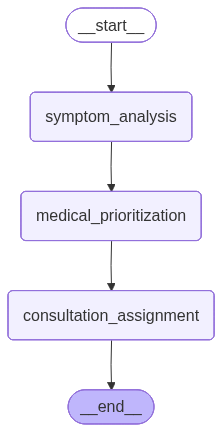

In [31]:
workflow

In [32]:
# -----------------------------------
# SAMPLE INPUT
# -----------------------------------

input_data = {
    "patient_name": "Anita Joseph",
    "fever": 102,
    "oxygen_level": 93,
    "heart_rate": 118,
    "symptom_duration": 4,
    "age": 67,
    "existing_conditions": "Diabetes, Hypertension"
}

In [33]:
# -----------------------------------
# RUN WORKFLOW
# -----------------------------------

result = workflow.invoke(input_data)

print("\n===== FINAL WORKFLOW OUTPUT =====")
print(result)


===== STEP 1: SYMPTOM ANALYSIS =====
SEVERITY: MODERATE

===== STEP 2: MEDICAL PRIORITIZATION =====
PRIORITY: PRIORITY_CONSULTATION

===== STEP 3: CONSULTATION ASSIGNMENT =====
ASSIGNMENT: Specialist Doctor

===== FINAL WORKFLOW OUTPUT =====
{'patient_name': 'Anita Joseph', 'fever': 102, 'oxygen_level': 93, 'heart_rate': 118, 'symptom_duration': 4, 'age': 67, 'existing_conditions': 'Diabetes, Hypertension', 'severity': 'MODERATE', 'priority': 'PRIORITY_CONSULTATION', 'consultation_assignment': 'Specialist Doctor'}
